# Batch-оценка регистрации вдох–выдох

Этот notebook **не запускает регистрацию заново**. Он читает сохранённые batch-артефакты и показывает независимую subject-level оценку.

Научные ограничения:

- fixed = выдох, moving = вдох;
- transform: `fixed-expiration → moving-inspiration` в локальной RAS+ системе, мм;
- экспертные landmarks и автоматически найденные keypoints не смешиваются;
- локальные изменения формы и толщины допустимы только после прохождения registration gate;
- единица статистического анализа — субъект.

**Техническое воспроизведение, 14.09.2026.** Ноутбук сохраняет историческую постановку и ограничения. Повторное исполнение проверяет расчёты и отображение; оно не меняет научный статус ветки. Тяжёлые результаты читаются из сохранённых пакетов с исходными проверками целостности. Источники и конфигурации используются из этой папки проекта.

In [1]:
# Portable execution support; scientific sources remain in this checkout.
import os
import sys
from pathlib import Path
_start = Path(os.environ.get("BREATH_NOTEBOOK_DIR", Path.cwd())).resolve()
_support = next((folder for parent in (_start, *_start.parents)
                 for folder in (parent, parent / "notebooks", parent / "breath geometry/notebooks")
                 if (folder / "execution_support.py").is_file()), None)
if _support is None:
    raise FileNotFoundError("Не найден notebooks/execution_support.py")
sys.path.insert(0, str(_support))
from execution_support import roots, copdgene_case_dir, lungct_input
REPO_ROOT, ARTIFACT_ROOT = roots()
repo_root = REPO_ROOT


In [2]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.lines import Line2D


artifact_paths = {
    "DIR-Lab COPDgene": ARTIFACT_ROOT / "results/registration/dirlab/benchmark.csv",
    "Learn2Reg LungCT (expert subset)": (
        ARTIFACT_ROOT
        / "results/registration/lungct_expert/benchmark.csv"
    ),
}
missing = [path.name for path in artifact_paths.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(
        "Нет batch-артефактов: " + ", ".join(missing)
        + ". Сначала выполните команды из docs/REGISTRATION_BENCHMARK.md."
    )

frames = []
for cohort, path in artifact_paths.items():
    frame = pd.read_csv(path)
    frame.insert(0, "cohort", cohort)
    frames.append(frame)
results = pd.concat(frames, ignore_index=True)
results["gate_pass"] = results["gate_pass"].astype(bool)

print(f"Загружено {len(results)} субъектов из {len(frames)} независимых batch-таблиц.")
print("В notebook не загружены DICOM/NIfTI и не выводятся локальные пути к медицинским данным.")

Загружено 13 субъектов из 2 независимых batch-таблиц.
В notebook не загружены DICOM/NIfTI и не выводятся локальные пути к медицинским данным.


## Результаты по субъектам

Здесь показаны только независимые экспертные landmarks. Улучшение TRE само по себе не означает прохождения gate.

In [3]:
table_columns = [
    "cohort",
    "subject_id",
    "expert_count",
    "expert_tre_before_mean_mm",
    "expert_tre_after_mean_mm",
    "expert_tre_after_p95_mm",
    "lung_dice_after",
    "lung_surface_p95_after_mm",
    "jacobian_p01",
    "nonpositive_jacobian_fraction",
    "gate_pass",
    "gate_reasons",
]
subject_table = results[table_columns].copy()
subject_table.columns = [
    "Выборка",
    "Субъект",
    "Expert points, n",
    "Mean TRE до, мм",
    "Mean TRE после, мм",
    "TRE p95 после, мм",
    "Lung Dice",
    "Lung surface p95, мм",
    "Jacobian p01",
    "Доля J≤0",
    "Gate",
    "Причины FAIL",
]
display(subject_table.round(3))

,Выборка,Субъект,"Expert points, n","Mean TRE до, мм","Mean TRE после, мм","TRE p95 после, мм",Lung Dice,"Lung surface p95, мм",Jacobian p01,Доля J≤0,Gate,Причины FAIL
0,DIR-Lab COPDgene,copd1,300,26.334,15.303,29.811,0.938,9.036,0.840,0.0,False,expert_tre_mean;expert_tre_p95;lung_surface_p95
1,DIR-Lab COPDgene,copd2,300,21.786,14.830,25.544,0.896,7.931,0.679,0.0,False,expert_tre_mean;expert_tre_p95;lung_dice;lung_...
2,DIR-Lab COPDgene,copd3,300,12.639,9.265,21.670,0.903,12.500,0.861,0.0,False,expert_tre_mean;expert_tre_p95;lung_surface_p95
3,DIR-Lab COPDgene,copd4,300,29.584,29.336,49.319,0.739,33.523,0.782,0.0,False,expert_tre_mean;expert_tre_p95;lung_dice;lung_...
4,DIR-Lab COPDgene,copd5,300,30.083,29.917,51.933,0.709,39.124,0.841,0.0,False,expert_tre_mean;expert_tre_p95;lung_dice;lung_...
5,DIR-Lab COPDgene,copd6,300,28.456,18.611,33.235,0.844,16.138,0.821,0.0,False,expert_tre_mean;expert_tre_p95;lung_dice;lung_...
6,DIR-Lab COPDgene,copd7,300,21.602,14.733,27.201,0.856,15.934,0.896,0.0,False,expert_tre_mean;expert_tre_p95;lung_dice;lung_...
7,DIR-Lab COPDgene,copd8,300,26.457,26.906,52.768,0.769,31.703,0.849,0.0,False,expert_tre_mean;expert_tre_p95;lung_dice;lung_...
8,DIR-Lab COPDgene,copd9,300,14.860,11.899,37.187,0.892,18.773,0.837,0.0,False,expert_tre_mean;expert_tre_p95;lung_dice;lung_...
9,DIR-Lab COPDgene,copd10,300,21.806,31.729,56.430,0.771,36.762,0.821,0.0,False,expert_tre_mean;expert_tre_p95;lung_dice;lung_...


In [4]:
summary_rows = []
for cohort, group in results.groupby("cohort", sort=False):
    after = group["expert_tre_after_mean_mm"]
    summary_rows.append(
        {
            "Выборка": cohort,
            "Субъектов": len(group),
            "TRE улучшился": int(
                (after < group["expert_tre_before_mean_mm"]).sum()
            ),
            "Gate пройден": int(group["gate_pass"].sum()),
            "Медиана mean TRE после, мм": after.median(),
            "Q1 mean TRE после, мм": after.quantile(0.25),
            "Q3 mean TRE после, мм": after.quantile(0.75),
            "Медиана lung Dice": group["lung_dice_after"].median(),
            "Случаи с J≤0": int(
                (group["nonpositive_jacobian_fraction"] > 0).sum()
            ),
        }
    )
cohort_summary = pd.DataFrame(summary_rows)
display(cohort_summary.round(3))

overall_after = results["expert_tre_after_mean_mm"]
print(
    "Все субъекты: медиана mean TRE после "
    f"{overall_after.median():.2f} мм "
    f"(IQR {overall_after.quantile(0.25):.2f}–"
    f"{overall_after.quantile(0.75):.2f} мм)."
)

,Выборка,Субъектов,TRE улучшился,Gate пройден,"Медиана mean TRE после, мм","Q1 mean TRE после, мм","Q3 mean TRE после, мм",Медиана lung Dice,Случаи с J≤0
0,DIR-Lab COPDgene,10,8,0,16.957,14.757,28.728,0.850,0
1,Learn2Reg LungCT (expert subset),3,3,0,4.520,4.087,8.841,0.917,0


Все субъекты: медиана mean TRE после 14.83 мм (IQR 11.90–26.91 мм).


## Диагностика gate

Предзаданные границы: mean expert TRE ≤ 2 мм, expert TRE p95 ≤ 5 мм, lung Dice ≥ 0.90, lung surface p95 ≤ 5 мм, Jacobian p01 ≥ 0.10, доля неположительных якобианов = 0.

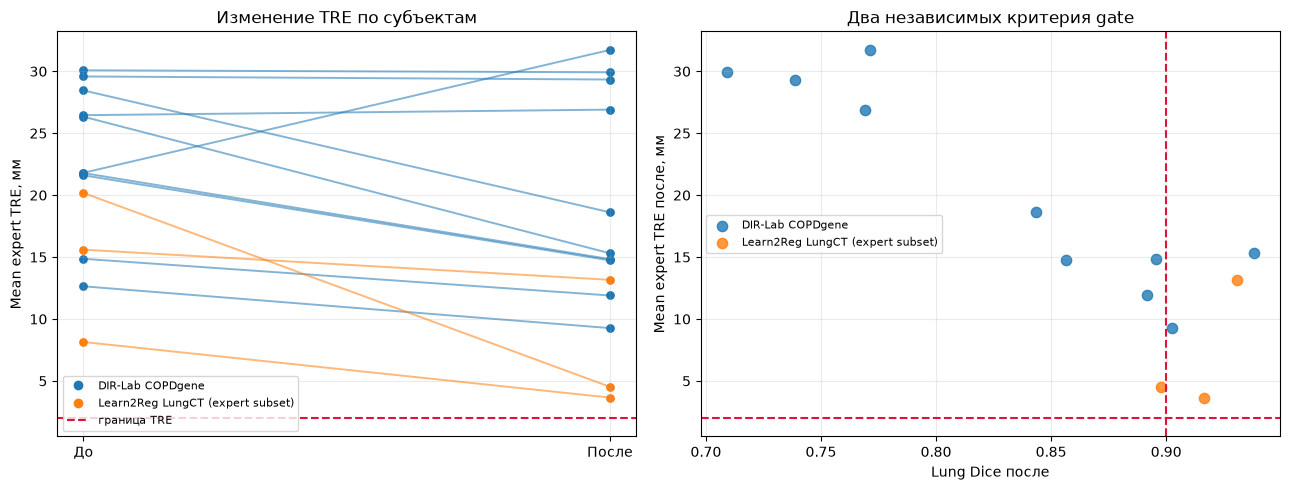

In [5]:
palette = {
    "DIR-Lab COPDgene": "#1f77b4",
    "Learn2Reg LungCT (expert subset)": "#ff7f0e",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for _, row in results.iterrows():
    color = palette[row["cohort"]]
    axes[0].plot(
        [0, 1],
        [row["expert_tre_before_mean_mm"], row["expert_tre_after_mean_mm"]],
        color=color,
        alpha=0.55,
        linewidth=1.4,
    )
    axes[0].scatter(
        [0, 1],
        [row["expert_tre_before_mean_mm"], row["expert_tre_after_mean_mm"]],
        color=color,
        s=28,
    )
axes[0].axhline(2.0, color="crimson", linestyle="--")
axes[0].set_xticks([0, 1], ["До", "После"])
axes[0].set_ylabel("Mean expert TRE, мм")
axes[0].set_title("Изменение TRE по субъектам")
axes[0].grid(alpha=0.25)

for cohort, group in results.groupby("cohort", sort=False):
    axes[1].scatter(
        group["lung_dice_after"],
        group["expert_tre_after_mean_mm"],
        s=55,
        alpha=0.8,
        color=palette[cohort],
        label=cohort,
    )
axes[1].axvline(0.90, color="crimson", linestyle="--")
axes[1].axhline(2.0, color="crimson", linestyle="--")
axes[1].set_xlabel("Lung Dice после")
axes[1].set_ylabel("Mean expert TRE после, мм")
axes[1].set_title("Два независимых критерия gate")
axes[1].grid(alpha=0.25)

legend_handles = [
    Line2D([0], [0], color=color, marker="o", linestyle="", label=cohort)
    for cohort, color in palette.items()
]
axes[0].legend(
    handles=legend_handles
    + [Line2D([0], [0], color="crimson", linestyle="--", label="граница TRE")],
    fontsize=8,
)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

,Число субъектов
gate_reasons,
lung_dice,9
expert_tre_mean,13
expert_tre_p95,13
lung_surface_p95,13


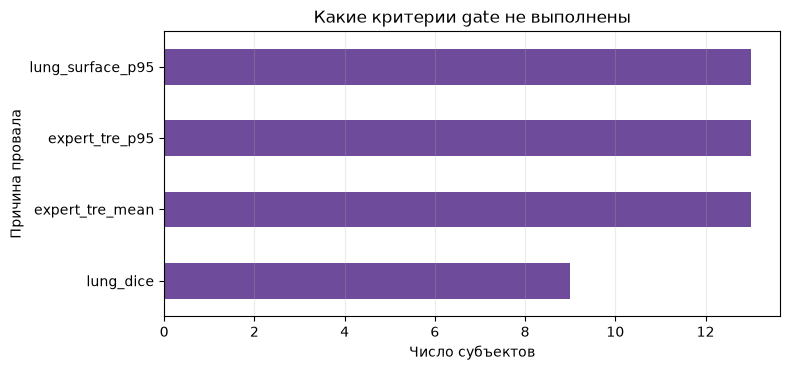

In [6]:
reason_counts = (
    results["gate_reasons"]
    .fillna("")
    .str.split(";")
    .explode()
    .loc[lambda values: values.ne("")]
    .value_counts()
    .sort_values()
)
display(reason_counts.rename("Число субъектов").to_frame())

ax = reason_counts.plot.barh(figsize=(8, 3.8), color="#6f4c9b")
ax.set_xlabel("Число субъектов")
ax.set_ylabel("Причина провала")
ax.set_title("Какие критерии gate не выполнены")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Expert landmarks отдельно от keypoints

Keypoints полезны для диагностики, но не заменяют независимую экспертную разметку и не участвуют в landmark-части gate.

In [7]:
lungct = results.loc[
    results["dataset_id"].eq("learn2reg_lungct"),
    [
        "subject_id",
        "expert_count",
        "expert_tre_after_mean_mm",
        "keypoint_count",
        "keypoint_tre_after_mean_mm",
    ],
].copy()
lungct.columns = [
    "Субъект",
    "Expert, n",
    "Expert TRE после, мм",
    "Keypoints, n",
    "Keypoint TRE после, мм",
]
display(lungct.round(2))

,Субъект,"Expert, n","Expert TRE после, мм","Keypoints, n","Keypoint TRE после, мм"
10,LungCT_0001,81,4.52,1322,7.89
11,LungCT_0002,100,13.16,2191,15.22
12,LungCT_0003,100,3.65,1566,5.19


## Provenance сохранённых артефактов

Хеши ниже позволяют убедиться, что notebook визуализирует именно те batch-таблицы, для которых сохранены параметры и версия кода.

In [8]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

artifact_hashes = pd.DataFrame(
    [
        {
            "Артефакт": path.relative_to(ARTIFACT_ROOT).as_posix(),
            "SHA-256": sha256_file(path),
        }
        for path in artifact_paths.values()
    ]
)
display(artifact_hashes)

provenance_rows = []
for folder in [
    ARTIFACT_ROOT / "results/registration/dirlab",
    ARTIFACT_ROOT / "results/registration/lungct_expert",
]:
    for path in sorted(folder.glob("*.json")):
        payload = json.loads(path.read_text(encoding="utf-8"))
        provenance = payload["provenance"]
        parameters = payload["parameters"]
        provenance_rows.append(
            {
                "code_version": provenance["code_version"],
                "manifest_sha256": provenance["pair_manifest_sha256"],
                "stages": " → ".join(parameters["stages"]),
                "resolutions": parameters["number_of_resolutions"],
                "samples": parameters["spatial_samples"],
                "iterations": "/".join(map(str, parameters["iterations"])),
                "grid_mm": parameters["final_grid_spacing_mm"],
                "seed": parameters["random_seed"],
                "registration_masks": parameters["use_registration_masks"],
            }
        )
provenance_table = pd.DataFrame(provenance_rows).drop_duplicates()
display(provenance_table)

,Артефакт,SHA-256
0,results/registration/dirlab/benchmark.csv,02582fc3470e4a57a3b9ce69f5bc0ab5d6ca018cf04b0d...
1,results/registration/lungct_expert/benchmark.csv,66ff91db8f508ac04088876a2cf15af6b0103f795c0621...


,code_version,manifest_sha256,stages,resolutions,samples,iterations,grid_mm,seed,registration_masks
0,238e9ac4d44fae5d38e4594feb9566a6e5b08eca,788f749c02dfab356ad8cb3d49414d9bf1bc0b60d23303...,rigid → affine → bspline,4,4096,128/128/256,24.0,20260730,False


In [9]:
passed = int(results["gate_pass"].sum())
total = len(results)
if passed == total:
    verdict = (
        f"## Итог: gate пройден у {passed}/{total}\n\n"
        "Парное измерение анатомических изменений разрешено для прошедших субъектов."
    )
else:
    verdict = (
        f"## Итог: gate пройден у {passed}/{total}\n\n"
        "**Текущий baseline нельзя использовать для парного изменения формы лёгких, "
        "толщины тканей или генерации выдоха по одной КТ.** "
        "Положительный Jacobian означает отсутствие folding, но не доказывает "
        "анатомическую точность соответствий."
    )
display(Markdown(verdict))

## Итог: gate пройден у 0/13

**Текущий baseline нельзя использовать для парного изменения формы лёгких, толщины тканей или генерации выдоха по одной КТ.** Положительный Jacobian означает отсутствие folding, но не доказывает анатомическую точность соответствий.